### Tässä tiedostossa tutkitaan ETL-prosessissa poistettua dataa

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from PIL import Image
import seaborn as sns
import glob
import gc
import os
from matplotlib.colors import LogNorm

# Aikavyöhykkeet ja aikaleimakäsittely
from datetime import datetime

In [19]:
# Hakemistot
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)

raw_path = os.path.join(project_root, "data", "raw")
processed_path = os.path.join(project_root, "data", "processed")

# Store config
import sys
sys.path.append(os.path.join(project_root, "config"))
from store_config import store_config

# Tiedostot
raw_files = sorted(glob.glob(os.path.join(raw_path, "*.csv")))
processed_files = sorted(glob.glob(os.path.join(processed_path, "*.parquet")))

# Myymäläalueen koordinaattiarvot
store_max_x = store_config["geometry"]["store_max_x_cm"]
store_max_y = store_config["geometry"]["store_max_y_cm"]

# Poimitaan node-nimet tiedostonimistä
raw_nodes = set(os.path.basename(f).replace(".csv", "") for f in raw_files)
processed_nodes = set(os.path.basename(f).replace(".parquet", "") for f in processed_files)
kept_nodes = sorted(processed_nodes)

print(f"Nykyinen hakemisto: {current_dir}")
print(f"Raw-tiedostoja: {len(raw_files)}")
print(f"Processed-tiedostoja: {len(processed_files)}")
print(f"Myymälän koko: {store_max_x} x {store_max_y} cm")

Nykyinen hakemisto: /home/suviniemittm25sai/code/projektiopinnot-1-datan-hallinta-laitetaan-parastamme/notebooks
Raw-tiedostoja: 31
Processed-tiedostoja: 21
Myymälän koko: 11206 x 5220 cm


### 1. Luokitellaan datan poistosyyt

In [22]:
class StoreDataCleaner:
    def __init__(self, config):
        self.config = config
        self.geom = config['geometry']
        self.logic = config['session_logic']
        self.motion = config['motion_filters']
        self.ops = config['operational_hours']
        self.gates = config['spatial_zones']['gates']

    def clean_spatial(self, df):
        mask = (df['x'] >= 0) & (df['x'] <= self.geom['store_max_x_cm']) & \
               (df['y'] >= 0) & (df['y'] <= self.geom['store_max_y_cm'])
        df = df[mask].copy()
        for name, coords in self.config['spatial_zones']['dead_zones'].items():
            x1, x2, y1, y2 = coords
            df = df[~((df['x'] >= x1) & (df['x'] <= x2) & (df['y'] >= y1) & (df['y'] <= y2))]
        return df

    def sessionize(self, df):
        df = df.sort_values(['node_id', 'timestamp'])
        df['dt'] = df.groupby('node_id')['timestamp'].diff().dt.total_seconds()
        df['new_session'] = (df['dt'] > self.logic['gap_threshold_s']) | df['dt'].isna()
        df['session_id'] = df.groupby('node_id')['new_session'].cumsum()
        df['final_sid'] = df['node_id'].astype(str) + "_" + df['session_id'].astype(str)
        return df

    def is_operational(self, timestamp):
        wd = timestamp.day_name()
        hr = timestamp.hour
        start, end = self.ops['sun'] if wd == 'Sunday' else self.ops['mon-sat']
        return start <= hr < end

    def validate_sessions(self, df):
        valid_data = []
        stats = []
        rejected_stats = []  # ← UUSI lista hylättyjen syille

        for sid, group in df.groupby('final_sid'):
            rejection_reason = None  # ← alustetaan tyhjäksi

            if len(group) < self.logic['min_points']:
                rejection_reason = 'liian_vahan_pisteita'
            else:
                start_time = group['timestamp'].min()
                if not self.is_operational(start_time):
                    rejection_reason = 'aukioloajan_ulkopuolella'
                else:
                    start_pt = group.iloc[0]
                    end_pt = group.iloc[-1]

                    s_x1, s_x2, s_y1, s_y2 = self.gates['sisäänkäynti']['coords']
                    is_start_valid = (s_x1 <= start_pt['x'] <= s_x2) and (s_y1 <= start_pt['y'] <= s_y2)

                    k_x1, k_x2, k_y1, k_y2 = self.gates['kassa']['coords']
                    is_end_valid = (k_x1 <= end_pt['x'] <= k_x2) and (k_y1 <= end_pt['y'] <= k_y2)

                    max_x = group['x'].max()
                    has_penetrated = max_x >= self.logic['min_store_penetration_x']

                    duration = (group['timestamp'].max() - start_time).total_seconds()
                    dx, dy = group['x'].diff().fillna(0)/100, group['y'].diff().fillna(0)/100
                    dist = np.sqrt(dx**2 + dy**2).sum()
                    avg_speed = dist / duration if duration > 0 else 0

                    if not (self.logic['min_time_s'] <= duration <= self.logic['max_time_s']):
                        rejection_reason = 'kesto_virheellinen'
                    elif dist < self.logic['min_dist_m']:
                        rejection_reason = 'matka_liian_lyhyt'
                    elif avg_speed < self.motion['min_avg_speed_ms']:
                        rejection_reason = 'nopeus_liian_alhainen'
                    elif not is_start_valid:
                        rejection_reason = 'ei_ala_sisaankaynnilta'
                    elif not is_end_valid:
                        rejection_reason = 'ei_lopu_kassalle'
                    elif not has_penetrated:
                        rejection_reason = 'ei_riittavaa_syvyytta'

            if rejection_reason:
                rejected_stats.append({
                    'sessio_id': sid,
                    'syy': rejection_reason
                })
                continue  # ← hylätään sessio

            # Hyväksytty sessio — sama kuin ennen
            valid_data.append(group)
            stats.append({
                'sessio_id': sid, 'start_time': start_time, 'kesto_min': duration / 60,
                'matka_m': dist, 'max_x': max_x, 'pisteet': len(group), 'nopeus_avg': avg_speed,
                'pvm': start_time.date(), 'tunti': start_time.hour
            })

        return (
            pd.concat(valid_data) if valid_data else pd.DataFrame(),
            pd.DataFrame(stats),
            pd.DataFrame(rejected_stats)
    )

cleaner = StoreDataCleaner(store_config) 

### 2. Tutkitaan mistä syystä dataa hylättiin ETL-prosessin läpäisseissä kärryissä

In [23]:
all_rejected = []
all_accepted = []
all_rejected_points = []

for node in kept_nodes:
    filepath = os.path.join(raw_path, f"{node}.csv")
    
    df = pd.read_csv(
        filepath,
        dtype={"node_id": str, "timestamp": str, "x": float, "y": float, "z": float, "q": float}
    )
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    
    df_spatial = cleaner.clean_spatial(df)
    df_sessionized = cleaner.sessionize(df_spatial)
    df_final, session_metrics, rejected_metrics = cleaner.validate_sessions(df_sessionized)
    
    # Tallennetaan hylättyjen sessioiden koordinaatit
    rejected_sids = set(rejected_metrics['sessio_id'])
    rejected_points = df_sessionized[df_sessionized['final_sid'].isin(rejected_sids)][['x', 'y', 'final_sid']].copy()
    rejected_points['node'] = node
    rejected_points = rejected_points.merge(rejected_metrics[['sessio_id', 'syy']], 
                                             left_on='final_sid', right_on='sessio_id')
    
    rejected_metrics['node_id'] = node
    session_metrics['node_id'] = node
    
    all_rejected.append(rejected_metrics)
    all_accepted.append(session_metrics)
    all_rejected_points.append(rejected_points)
    
    print(f"{node}: hyväksytty {len(session_metrics)}, hylätty {len(rejected_metrics)}")
    
    del df, df_spatial, df_sessionized, df_final

rejected_all = pd.concat(all_rejected, ignore_index=True)
accepted_all = pd.concat(all_accepted, ignore_index=True)
rejected_points_all = pd.concat(all_rejected_points, ignore_index=True)

print(f"\nYhteensä hyväksytty: {len(accepted_all)}")
print(f"Yhteensä hylätty: {len(rejected_all)}")
print(f"Hylättyjä pisteitä: {len(rejected_points_all):,}")

node_3200: hyväksytty 136, hylätty 5598
node_3224: hyväksytty 139, hylätty 3903
node_3240: hyväksytty 126, hylätty 5424
node_51719: hyväksytty 135, hylätty 5175
node_51735: hyväksytty 125, hylätty 3413
node_51751: hyväksytty 122, hylätty 4193
node_51850: hyväksytty 135, hylätty 5337
node_51866: hyväksytty 114, hylätty 3337
node_51889: hyväksytty 103, hylätty 4280
node_51968: hyväksytty 96, hylätty 3489
node_51976: hyväksytty 118, hylätty 4815
node_51992: hyväksytty 119, hylätty 3783
node_52003: hyväksytty 108, hylätty 4822
node_52023: hyväksytty 126, hylätty 4408
node_52099: hyväksytty 123, hylätty 4151
node_52535: hyväksytty 142, hylätty 5486
node_53011: hyväksytty 124, hylätty 2632
node_53130: hyväksytty 125, hylätty 2735
node_53924: hyväksytty 120, hylätty 4706
node_53936: hyväksytty 151, hylätty 4170
node_54016: hyväksytty 159, hylätty 4738

Yhteensä hyväksytty: 2646
Yhteensä hylätty: 90595
Hylättyjä pisteitä: 34,048,779


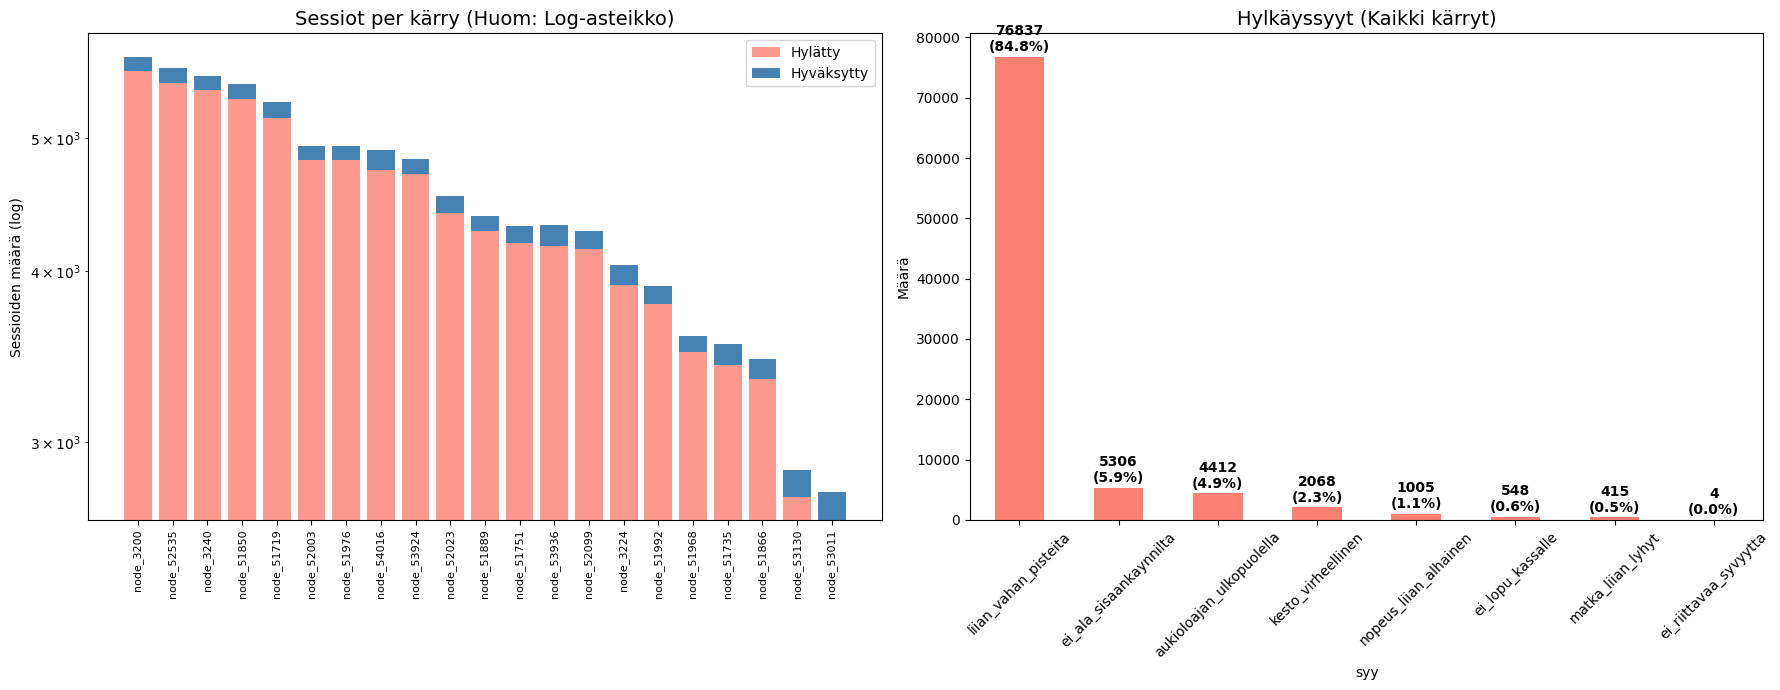

In [28]:
# --- DATAN VALMISTELU ---
node_stats = accepted_all.groupby('node_id').size().reset_index(name='hyväksytty')
node_rejected = rejected_all.groupby('node_id').size().reset_index(name='hylätty')
node_stats = node_stats.merge(node_rejected, on='node_id', how='outer').fillna(0)
node_stats = node_stats.sort_values('hylätty', ascending=False)

# Piirretään
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Vasemmalla: stacked bar per kärry (LOG-asteikolla) ---
ax1 = axes[0]
x = range(len(node_stats))
ax1.bar(x, node_stats['hylätty'], label='Hylätty', color='salmon', alpha=0.8)
ax1.bar(x, node_stats['hyväksytty'], bottom=node_stats['hylätty'], label='Hyväksytty', color='steelblue')

# Käytetään logaritmiasteikkoa, jotta pienetkin hyväksytyt sessiot näkyvät
ax1.set_yscale('log') 
ax1.set_xticks(x)
ax1.set_xticklabels(node_stats['node_id'], rotation=90, ha='center', fontsize=8)
ax1.set_title('Sessiot per kärry (Huom: Log-asteikko)', fontsize=14)
ax1.set_ylabel('Sessioiden määrä (log)')
ax1.legend()

# --- Oikealla: hylkäyssyyt koko datassa ---
ax2 = axes[1]
syyt = rejected_all['syy'].value_counts()
# Lasketaan prosentit palkkien päälle
total_rej = syyt.sum()
syyt.plot(kind='bar', ax=ax2, color='salmon')

# Lisätään lukumäärät ja prosentit pylväiden päälle selkeyden vuoksi
for i, v in enumerate(syyt):
    pct = (v / total_rej) * 100
    ax2.text(i, v + (total_rej*0.01), f'{v}\n({pct:.1f}%)', ha='center', fontweight='bold')

ax2.set_title('Hylkäyssyyt (Kaikki kärryt)', fontsize=14)
ax2.set_ylabel('Määrä')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Analyysi

Sessiot
- Hylkäysprosentti on todella dramaattinen jokaisella kärryllä. Sessiokriteerit eivät täyty suurimmassa osassa.
- Kärryt ovat keskenään hyvin tasaisia
- Node_53011 ja node_53130 erottuvat pienimmällä kokonaismäärällä

Hylkäyssyyt
- liian_vahan_pisteita dominoi täysin

### 3. Tutkitaan yhden kärryn poistettua dataa (nopeus, pysähdys, kohina)

In [14]:
# Valitaan testitiedosto
f_raw = raw_files[0]

# Luetaan raakadata
df = pd.read_csv(f_raw, usecols=["node_id", "timestamp", "x", "y"])
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['node_id', 'timestamp'])

# Lasketaan nopeus (cm/s)
dt = df.groupby('node_id')['timestamp'].diff().dt.total_seconds()
dist = np.sqrt(df.groupby('node_id')['x'].diff()**2 + df.groupby('node_id')['y'].diff()**2)
df['speed'] = dist / dt

# --- EROTTELLU ---
# 1. Kohina/Pysähdykset (Nopeus < 5 cm/s tai NaN)
noise_mask = (df['speed'] < 5) | (df['speed'].isna())
noise_df = df[noise_mask]

# 2. Teleportit (Nopeus > 250 cm/s)
teleport_mask = (df['speed'] > 250)
teleport_df = df[teleport_mask]

# 3. Validi liike (5 - 250 cm/s)
valid_df = df[(df['speed'] >= 5) & (df['speed'] <= 250)]

print(f"Yhteensä signaaleja: {len(df)}")
print(f"Pysähdyksiä/Kohinaa: {len(noise_df)} ({len(noise_df)/len(df)*100:.1f}%)")
print(f"Teleportteja: {len(teleport_df)} ({len(teleport_df)/len(df)*100:.1f}%)")
print(f"Validia liikettä: {len(valid_df)} ({len(valid_df)/len(df)*100:.1f}%)")

Yhteensä signaaleja: 6489294
Pysähdyksiä/Kohinaa: 1815909 (28.0%)
Teleportteja: 68819 (1.1%)
Validia liikettä: 4604566 (71.0%)


### 2. Tutkitaan missä päin myymälää on pysähdyksiä ja kohinaa (yksi kärry)

In [24]:
# Asetetaan rajat vastaamaan raakadataa ja myymälän kokonaisleveyttä (11206 cm)
img_x_min = -800
img_x_max = 10406
img_y_min = 0
img_y_max = 5220

# Luodaan extent-lista Matplotlibiä varten
# Järjestys: [vasen, oikea, ala, ylä] -> y-akseli käännettynä (0 ylhäällä)
EXT = [img_x_min, img_x_max, 0, img_y_max]

# Polku pohjakarttaan
img_path = os.path.join(project_root, "kauppa.jpg")

# Ladataan pohjakartta
img = Image.open(img_path)

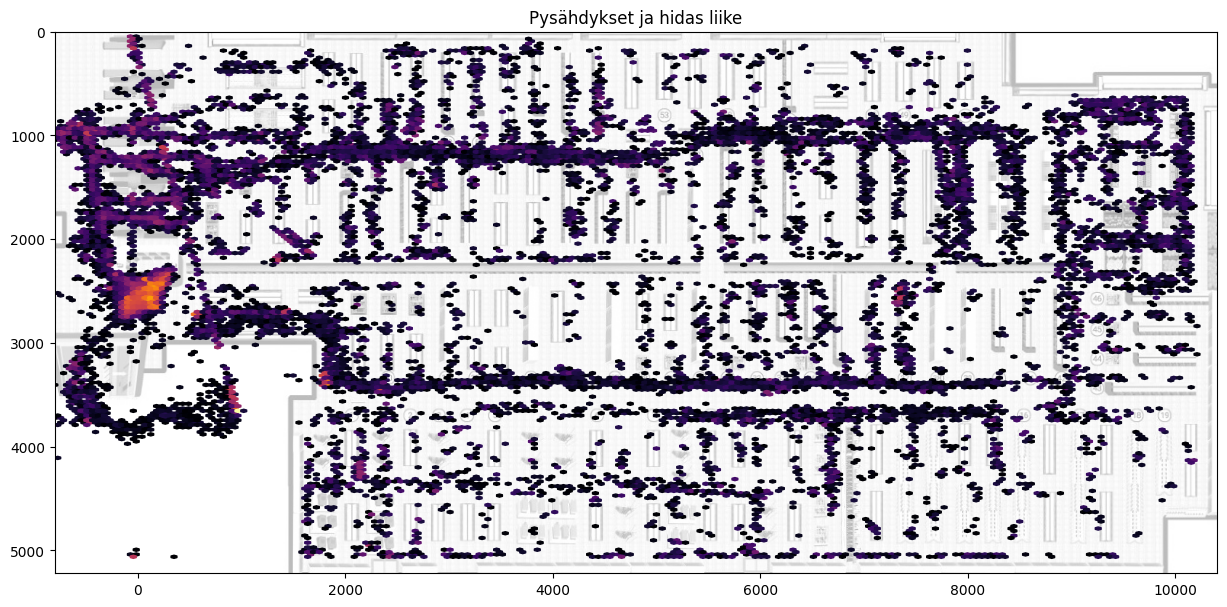

In [25]:
import IPython.display

# 1. Luodaan kuva-objekti
puhdas_fig, puhdas_ax = plt.subplots(figsize=(15, 10))

# 2. Piirretään kartta ja data
puhdas_ax.imshow(img, extent=[img_x_min, img_x_max, 0, img_y_max], origin='lower', alpha=0.5)

# Käytetään eri väriä (esim. 'inferno'), jotta tiedämme että tämä on UUSI kuva
puhdas_ax.hexbin(noise_df['x'].values, noise_df['y'].values, 
                 gridsize=200, 
                 extent=[img_x_min, img_x_max, 0, img_y_max], 
                 cmap='inferno', 
                 mincnt=5, 
                 bins='log')

puhdas_ax.set_xlim(img_x_min, img_x_max)
puhdas_ax.set_ylim(0, img_y_max)
puhdas_ax.invert_yaxis()
puhdas_ax.set_title("Pysähdykset ja hidas liike")

# 3. Näytetään kuva
plt.show()

### 3. Tutkitaan missä päin myymälää on teleporttausliikettä (yksi kärry)

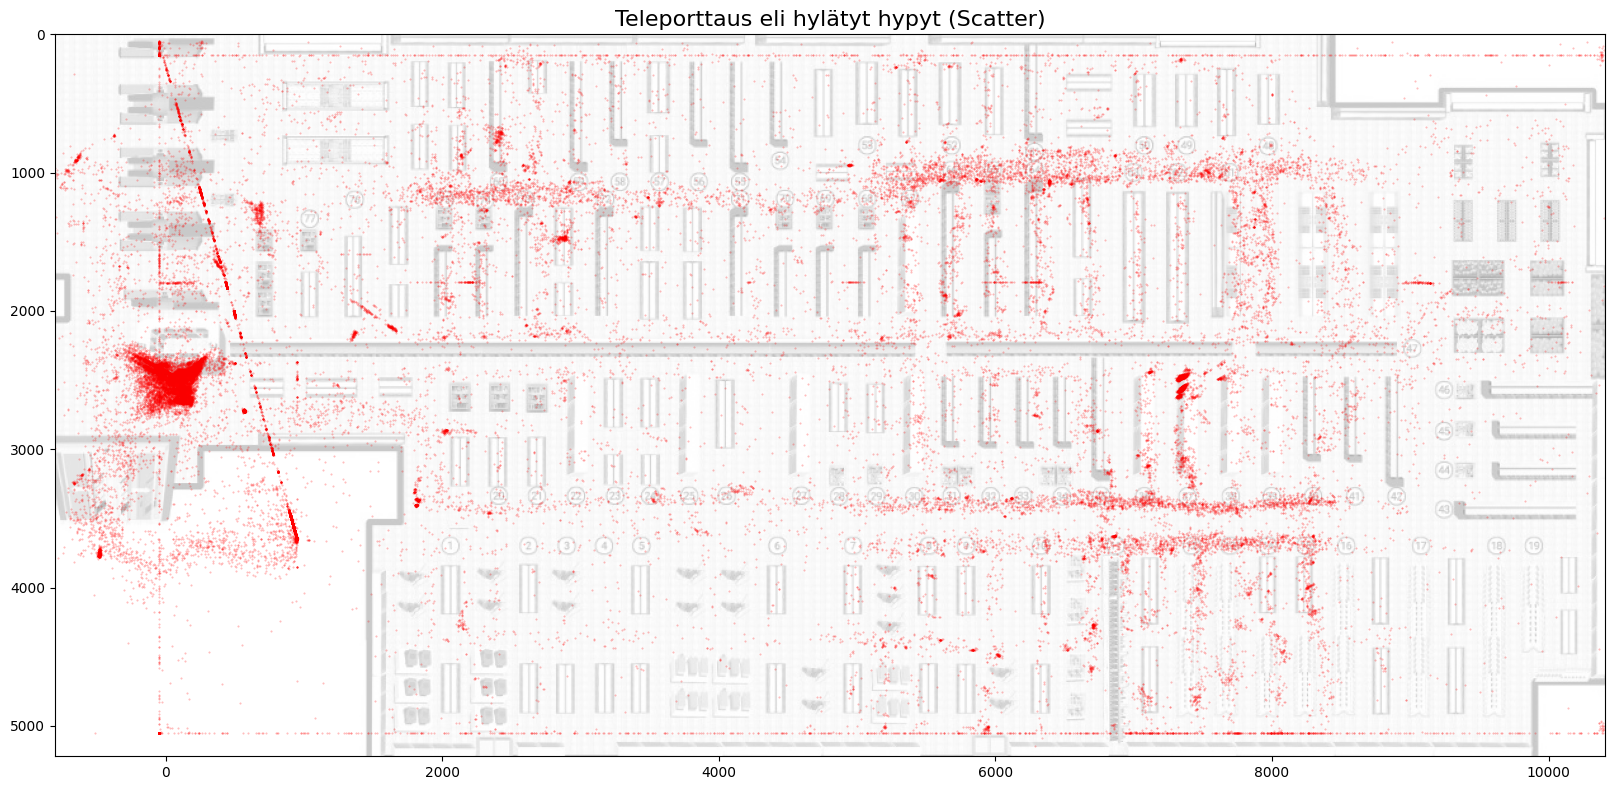

In [29]:
# Luodaan iso kuva
plt.figure(figsize=(20, 12))

# Taustakuva
plt.imshow(img, extent=[img_x_min, img_x_max, 0, img_y_max], origin='lower', alpha=0.4)

# Scatter-pisteet (teleportit)
# Käytetään hyvin pieniä pisteitä (s=0.1), jotta ne eivät peitä koko kuvaa
plt.scatter(teleport_df['x'].values, teleport_df['y'].values, 
            s=0.2, color='red', alpha=0.3)

plt.xlim(img_x_min, img_x_max)
plt.ylim(0, img_y_max)
plt.gca().invert_yaxis()

plt.title("Teleporttaus eli hylätyt hypyt (Scatter)", fontsize=16)
plt.show()

### Analyysi

Kärryn "kotipesä" (Latauspiste)
- Vasemmassa reunassa (noin x=0, y=2500) oleva kirkas alue on paikka, jossa kärry on viettänyt valtaosan ajastaan. Koska siinä on 1,8 miljoonaa pistettä, laite on todennäköisesti nököttänyt siinä päiviä tai viikkoja lähettäen dataa koko ajan.

Kaupan hyllyvälit
- Vaikka latauspiste "huutaa" lujaa, näet inferno-kuvassa hienosti mustia ja violetteja pistejonoja ympäri myymälää. Kärry on kulkenut lähes jokaisen käytävän läpi.

Suosituimmat käytävät
- Ne kohdat, joissa on kirkkaampaa violettia hyllyjen välissä, ovat paikkoja, joissa kärry on pysähtynyt pidempään (esim. asiakas on vertaillut tuotteita tai täyttänyt hyllyä).

- Punainen "Teleporttaus"-kuva kertoo, missä kohtaa myymälää paikannus on epävakain

Latauspisteen kohina
- Valtava punainen rypäs latauspisteessä kertoo, että sähköinen ympäristö ehkä häiritsee signaalia, jolloin laite "hyppii" paikallaan.

Käytävien suorat viivat
- Pitkiä punaisia viivoja kulkee hyllyjen läpi. Ne ovat hetkiä, jolloin yhteys on pätkäissyt ja laite on "teleportannut" pisteestä A pisteeseen B.